##### Импорт библиотек и настройки 

In [51]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Настройки отображения
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Настройки графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


##### Общая информация о датасете

In [52]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

print(f"Размер датасета: {df.shape}")   # Размер
print(df.columns.tolist())              # Названия колонок
print(df.head())                        # Первые 5 строк

Размер датасета: (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34   

In [53]:
# Типы данных и пропуски
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [54]:
# Статистика по числовым признакам
print(df.describe().round(3))

       SeniorCitizen    tenure  MonthlyCharges
count       7043.000  7043.000        7043.000
mean           0.162    32.371          64.762
std            0.369    24.559          30.090
min            0.000     0.000          18.250
25%            0.000     9.000          35.500
50%            0.000    29.000          70.350
75%            0.000    55.000          89.850
max            1.000    72.000         118.750


In [55]:
# Статистика по категориальным признакам
print(df.describe(exclude='number'))

        customerID gender Partner Dependents PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling     PaymentMethod TotalCharges Churn
count         7043   7043    7043       7043         7043          7043            7043           7043         7043             7043        7043        7043            7043            7043             7043              7043         7043  7043
unique        7043      2       2          2            2             3               3              3            3                3           3           3               3               3                2                 4         6531     2
top     7590-VHVEG   Male      No         No          Yes            No     Fiber optic             No           No               No          No          No              No  Month-to-month              Yes  Electronic check         20.2    No
freq             1   3555   

##### Обработка пропусков

In [56]:
# Пропуски
print("Пропуски по колонкам:")
# Ищем где значение NaN и считаем их количество
print(df.isnull().sum())

# Ищем где значение пустое
missed_cols = [col for col in df.columns if (df[col] == ' ').sum() > 0]
print(f"Колонки с пропусками: {missed_cols}")
misses = [(df[col] == ' ').sum() for col in missed_cols]
print(f"Всего пропусков: {sum(misses)}")
for col, count in zip(missed_cols, misses):
    print(f'В колонке {col} найдено пропусков: {count}')
print(f"Процент пропусков: {sum(misses) / df.size * 100:.3f}%")

# Дубликаты
print(f"Дубликаты строк: {df.duplicated().sum()}")

Пропуски по колонкам:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Колонки с пропусками: ['TotalCharges']
Всего пропусков: 11
В колонке TotalCharges найдено пропусков: 11
Процент пропусков: 0.007%
Дубликаты строк: 0


Пропуски в колонке TotalCharges, дубликатов нет. Необходимо заполнить пропуски.

In [57]:
#Преобразуем колонку TotalCharges в числовой тип данных
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Избавляемся от пропусков. TotalCharges = tenure * MonthlyCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])
# Проверяем
print((df['TotalCharges'] == ' ').sum())

# Сохраняем очищенный датасет
Path('../data/processed').mkdir(exist_ok=True)
df.to_csv('../data/processed/clean_data.csv', index=False)

0


Теперь данные готовы к анализу

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Доля оттока: 26.5%


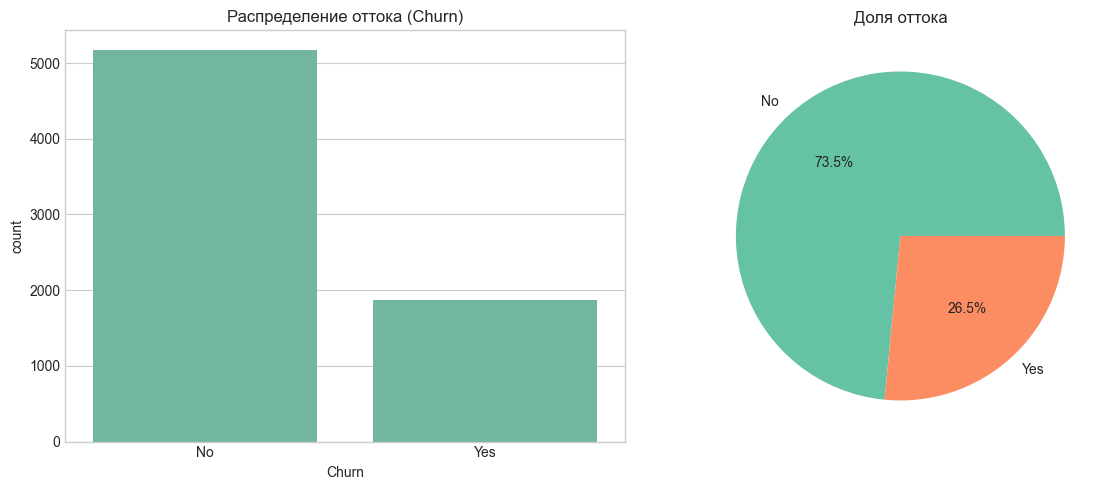

In [58]:
# Распределение
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"Доля оттока: {churn_counts['Yes'] / len(df) * 100:.1f}%")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Распределение оттока (Churn)')
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#66c2a5', '#fc8d62'])
axes[1].set_title('Доля оттока')

plt.tight_layout()
plt.savefig('../images/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

##### Анализ категориальных признаков: 

Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Contract:
         Contract  Total  Churn_Rate_percent
0  Month-to-month   3875                42.7
1        One year   1473                11.3
2        Two year   1695                 2.8


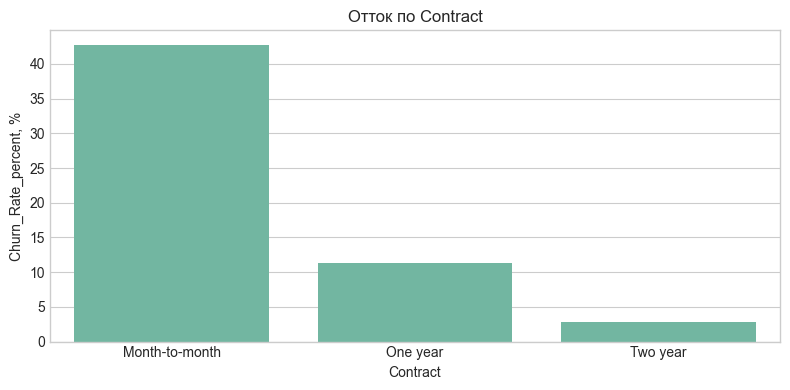

InternetService:
  InternetService  Total  Churn_Rate_percent
1     Fiber optic   3096                41.9
0             DSL   2421                19.0
2              No   1526                 7.4


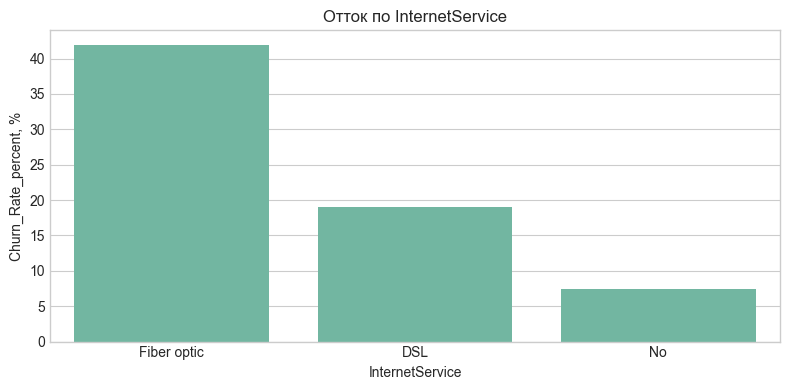

OnlineSecurity:
        OnlineSecurity  Total  Churn_Rate_percent
0                   No   3498                41.8
2                  Yes   2019                14.6
1  No internet service   1526                 7.4


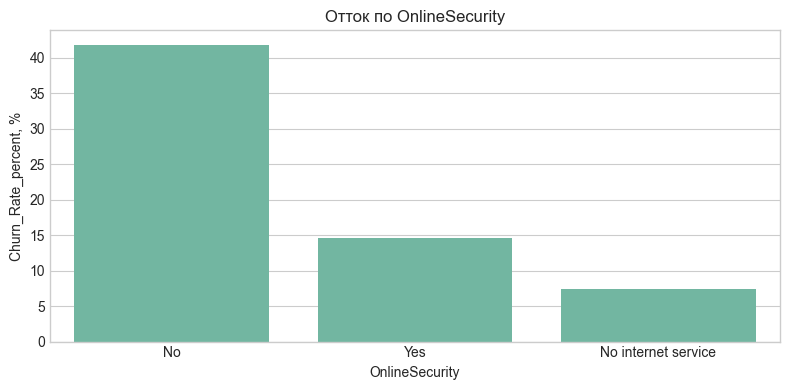

PaymentMethod:
               PaymentMethod  Total  Churn_Rate_percent
2           Electronic check   2365                45.3
3               Mailed check   1612                19.1
0  Bank transfer (automatic)   1544                16.7
1    Credit card (automatic)   1522                15.2


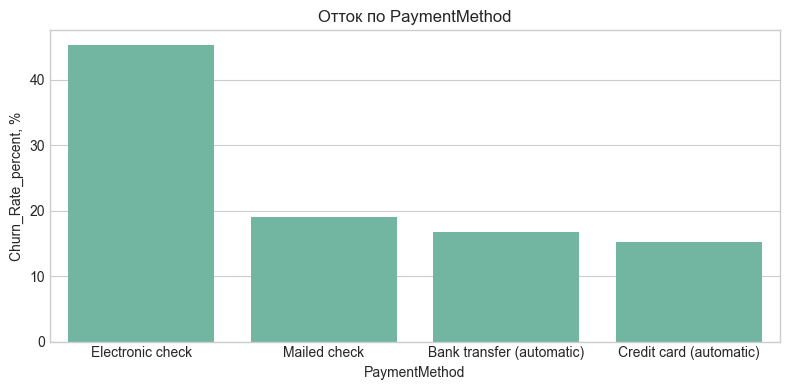

In [59]:
# Список категориальных признаков
category_cols = df.select_dtypes(exclude='number').columns.tolist()
category_cols.remove('customerID')
category_cols.remove('Churn')
print(f"Категориальные признаки: {category_cols}")

# Функция для анализа категориальных признаков
def analyze_categorical(col):
    summary = df.groupby(col, as_index=False).agg(
        Total=('Churn', 'count'), 
        Churn_Rate_percent=('Churn', lambda x: (x == 'Yes').mean() * 100)
    )
    print(f"{col}:")
    summary_sorted = summary.sort_values('Churn_Rate_percent', ascending=False).round(1)
    
    #summary_sorted = summary.sort_values('Churn_Rate_percent', ascending=False)
    print (summary_sorted)

    if df[col].nunique() <= 10:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=summary_sorted, x=col, y='Churn_Rate_percent',       
                    errorbar=None)
        plt.ylabel('Churn_Rate_percent, %')
        plt.title(f'Отток по {col}')
        plt.tight_layout()
        plt.show()

# Анализ ключевых признаков
key_cats = ['Contract', 'InternetService', 'OnlineSecurity', 'PaymentMethod']
for col in key_cats:
    analyze_categorical(col)

##### Анализ числовых признаков

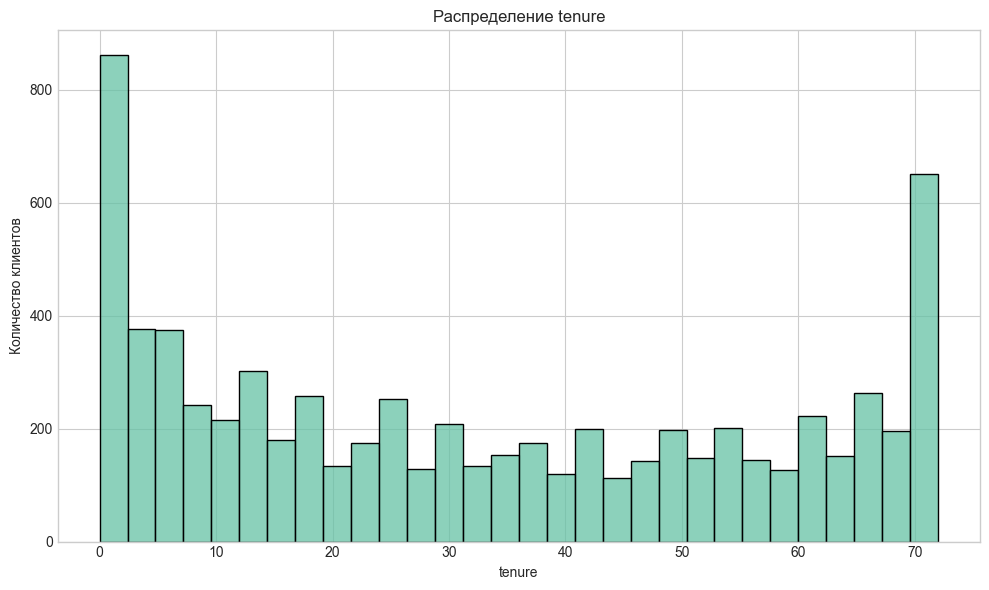

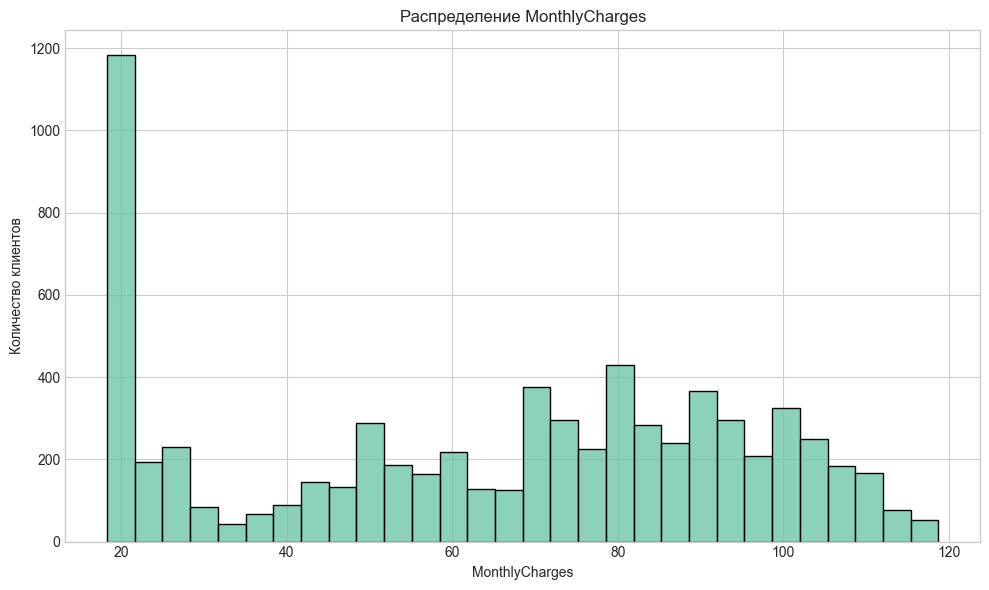

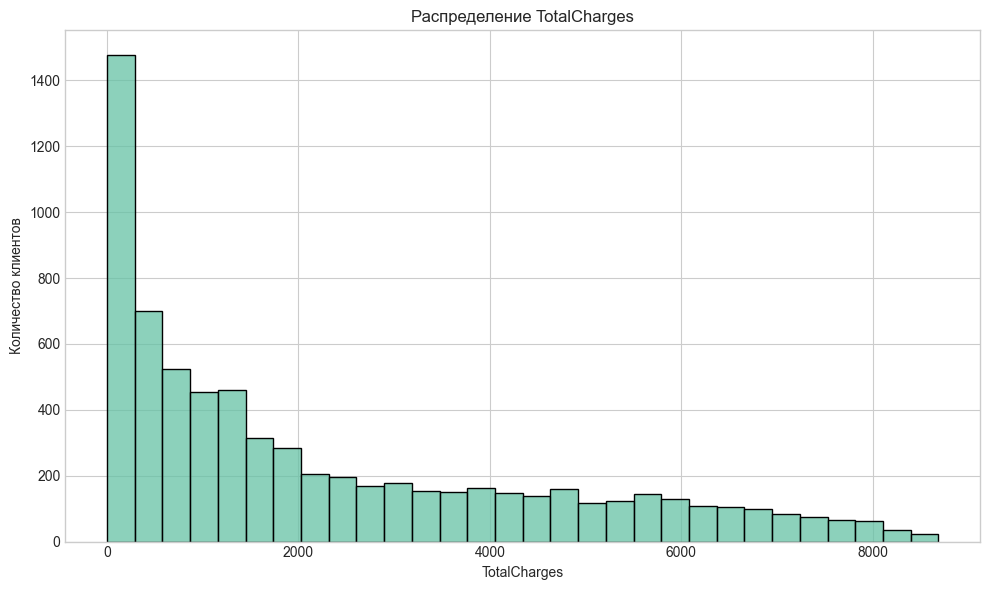

In [60]:
# Список числовых признаков
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Визуализация
for col in num_cols:
    df[col].describe

    sns.histplot(df[col], bins=30)
    plt.title(f'Распределение {col}')
    plt.ylabel('Количество клиентов')
    plt.tight_layout()
    plt.show()
    

##### Поиск корреляций 

<Figure size 1000x600 with 0 Axes>

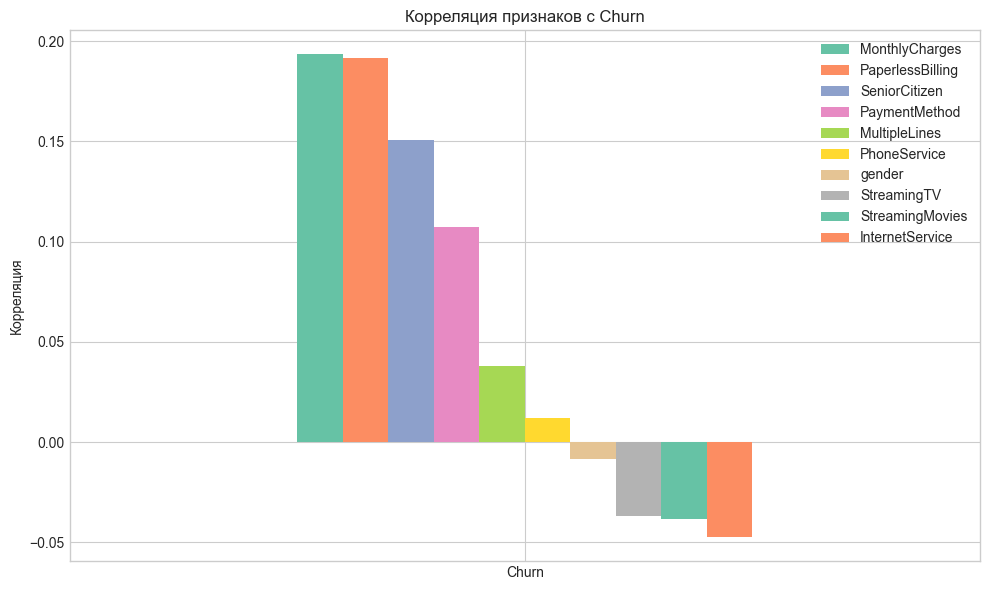

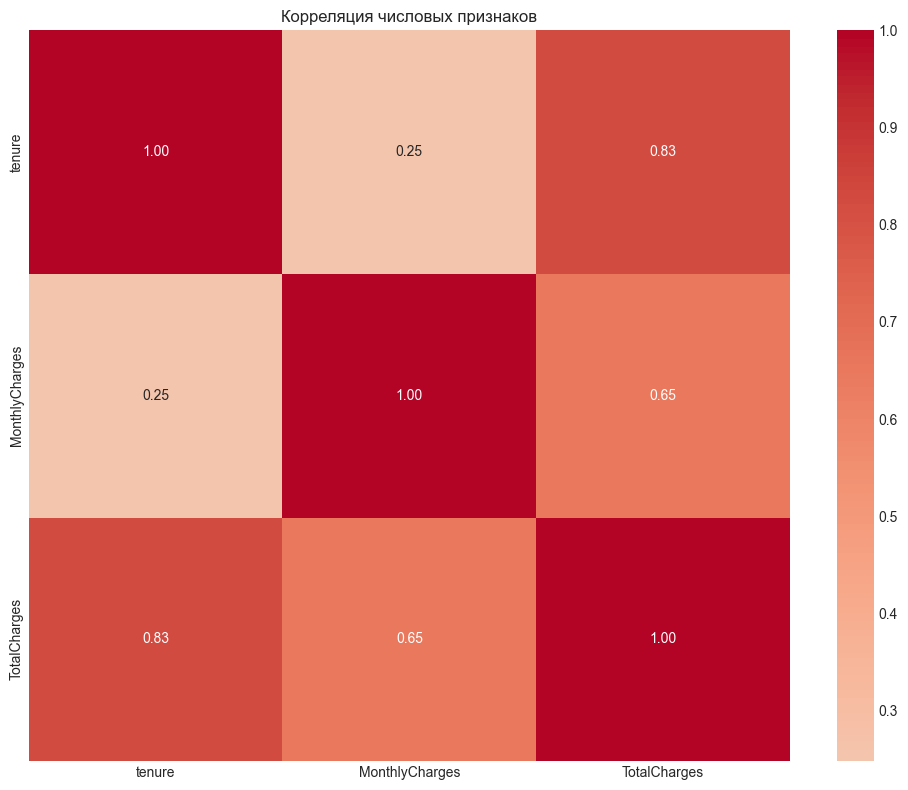

In [61]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

# Label Encoding для категориальных признаков
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Корелляция с оттоком клиентов Churn
corr_with_churn = df_encoded.drop('customerID', axis=1).corr()['Churn'].sort_values(ascending=False)
corr_with_churn = corr_with_churn.drop('Churn')
# Убираем часть данных, с которыми Churn коррелирует очень мало
corr_with_churn = corr_with_churn[:10] 
# Визуализация
plt.figure()
corr_with_churn.to_frame().T.plot(kind='bar')
plt.title('Корреляция признаков с Churn')
plt.xticks(rotation=0)
plt.ylabel('Корреляция')
plt.tight_layout()
plt.savefig('../images/correlation_with_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# Тепловая карта корреляции между числовыми признаками
plt.figure(figsize=(10, 8))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

##### Мультивариативный анализ

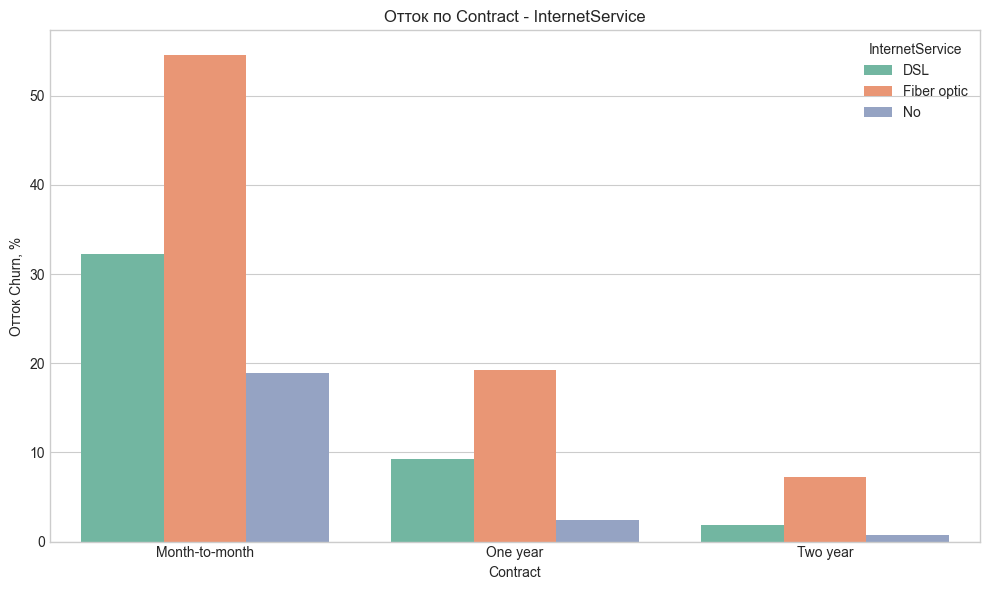

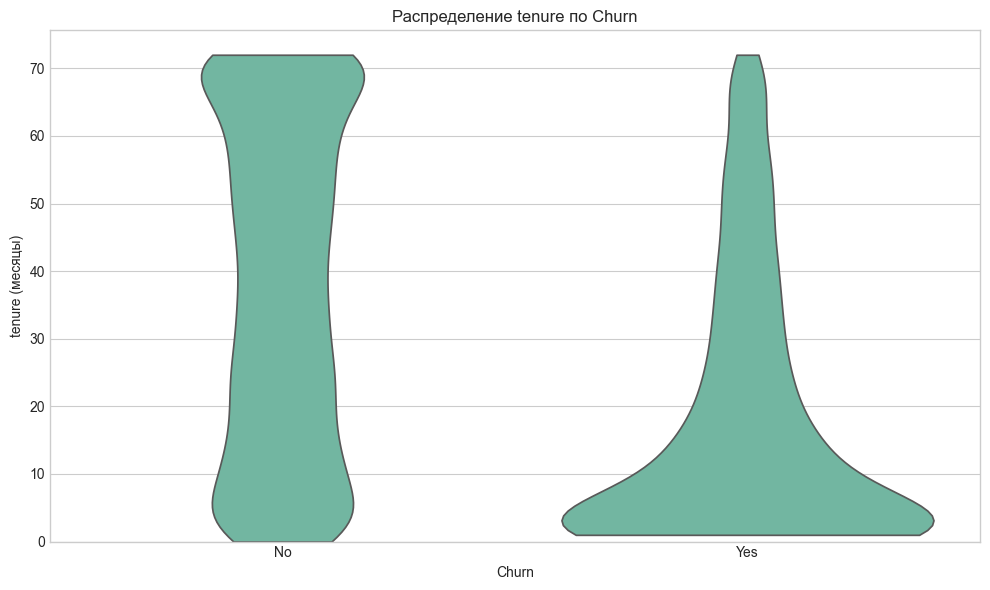

Отток среди новых и старых клиентов:
Новые клиенты (tenure < 12): 48.3%
Старые клиенты (tenure >= 12): 17.5%
Разница: 30.8%


In [62]:
# 1. Анализ Contract - InternetService
plt.figure()
sns.barplot(data=df, x='Contract', hue='InternetService',
            y=df['Churn'].map({'No': 0, 'Yes': 100}), 
            errorbar=None)
plt.title('Отток по Contract - InternetService')
plt.ylabel('Отток Churn, %')
plt.tight_layout()
plt.savefig('../images/contract_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Анализ tenure - Churn
plt.figure()
sns.violinplot(data=df, x='Churn', y='tenure', 
               inner=None, cut=0)
plt.title('Распределение tenure по Churn')
plt.xlabel('Churn')
plt.ylabel('tenure (месяцы)')
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('../images/tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# Создаем признак is_new_client - новый клиент (tenure < 12 месяцев)
df['is_new_client'] = (df['tenure'] < 12).astype(int)
# Анализ оттока для новых клиентов
new_client_churn = df.groupby('is_new_client')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print('Отток среди новых и старых клиентов:')
print(f"Новые клиенты (tenure < 12): {new_client_churn[1]:.1f}%")
print(f"Старые клиенты (tenure >= 12): {new_client_churn[0]:.1f}%")
print(f"Разница: {new_client_churn[1] - new_client_churn[0]:.1f}%")


# Сохраняем датасет с новым признаком is_new_client
Path('../data/processed').mkdir(exist_ok=True)
df.to_csv('../data/processed/result_data.csv', index=False)

## ИТОГИ EDA

### Данные
- Размер: 7,043 клиента, 21 признак
- Пропуски: 11 в `TotalCharges` → заполнили по формуле `TotalCharges = MonthlyCharges * tenure`
- Дубликаты: нет

### Целевая переменная
- Отток (Churn): 26.5%

### Ключевые инсайты

1. **Contract** — самый сильный предиктор:
   - Month-to-month: 42.7% оттока
   - One year: 11.3% оттока
   - Two year: 2.8% оттока
   - **Вывод**: клиенты на месячном контракте уходят в 15 раз, чем на двухлетнем

2. **tenure < 12 месяцев** — новые клиенты, группа высокого риска:
   - Новые клиенты: 48.3% оттока
   - Старые клиенты: 17.5% оттока
   - Разница: 30.8%
   - **Рекомендация**: предлагать скидки и бонусы в первые 12 месяцев

3. **InternetService - OnlineSecurity**:
   - Fiber optic: 41.9% оттока
   - DSL: 19.0% оттока
   - Без OnlineSecurity: 41.8% оттока
   - С OnlineSecurity: 14.6% оттока
   - **Разница**: 27.2%
   - **Рекомендация**: обязательно предлагать OnlineSecurity при подключении Fiber optic

4. **PaymentMethod = Electronic check**:
   - Electronic check: 45.3% оттока
   - Mailed check: 19.1% оттока
   - Bank transfer (automatic): 16.7% оттока
   - Credit card (automatic): 15.2% оттока
   - **Гипотеза**: автоматические платежи снижают отток в 3 раза

### Гипотезы для модели
- Модель должна хорошо предсказывать отток среди новых клиентов (tenure < 12)
- Важно учесть взаимодействие: InternetService - OnlineSecurity
- Добавить признаки: `is_new_client` (tenure < 12)
- Electronic check как фактор риска

### Риски
- Классы несбалансированы (73.5% / 26.5%) → использовать class_weight или SMOTE
- Высокая корреляция MonthlyCharges и TotalCharges → можно оставить только MonthlyCharges, так как он более информативный
- Month-to-month контракты доминируют в оттоке → фокус на удержании